# 📊 Coupling Metrics
## Part 1
Interactive notebook for generating software coupling metric visualizations.

## Metrics Covered
1. **Instability (I)** = Ce / (Ce + Ca)
2. **Abstractness (A)** = Na / Nc
3. **Distance from Main Sequence (D)** = |A + I - 1|

## Quick Start
1. Run "Setup & Configuration" cell first
2. Modify parameters in the config dictionaries
3. Re-run visualization cells to see changes
4. Export with `plt.savefig()` calls

In [1]:
# ============================================================
# SETUP & CONFIGURATION - Run this cell first!
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle, Polygon
from matplotlib.colors import ListedColormap, LightSource
import matplotlib.gridspec as gridspec

# Enable inline plotting
%matplotlib inline

# For higher-res displays (optional, comment out if issues)
%config InlineBackend.figure_format = 'retina'

print("✅ Setup complete!")

✅ Setup complete!


In [2]:
# ============================================================
# 🎨 COLOR PALETTE CONFIGURATION
# ============================================================
# Modify these to change the look of all visualizations

CONFIG = {
    # Background
    'background': '#FCF5E5',

    # Instability gradient colors (I = 0 to I = 1)
    'instability': {
        'white': (1.0, 1.0, 1.0),           # I ≈ 0
        'teal_light': '#6AD8D8',            # Stable zone
        'teal_dark': '#0D3D3D',
        'bronze_light': '#E0B060',          # Mostly stable
        'bronze_dark': '#5A3A12',
        'darkest_red': '#3A0808',           # I = 0.5 center
        'copper_light': '#E89048',          # Borderline
        'copper_dark': '#6A3210',
        'purple_light': '#8A4A9A',          # Unstable
        'purple_dark': '#2A0A3A',
        'black': (0.0, 0.0, 0.0),           # I = 1
    },

    # Main Sequence zones
    'zones': {
        'pain': '#E8B4B4',        # Zone of Pain (soft red)
        'useless': '#B4B4E8',     # Zone of Uselessness (soft blue)
        'main_seq': '#4CAF50',    # Main Sequence line (green)
    },

    # Mesh resolution
    'mesh_points': 200,
    'mesh_exponent': 2.5,  # For exponential mesh near origin

    # Export settings
    'dpi': 200,
    'format': 'png',  # 'png' or 'svg'
}

print("🎨 Color configuration loaded")
print(f"   Background: {CONFIG['background']}")
print(f"   Mesh resolution: {CONFIG['mesh_points']}×{CONFIG['mesh_points']}")

🎨 Color configuration loaded
   Background: #FCF5E5
   Mesh resolution: 200×200


In [3]:
# ============================================================
# 🔧 HELPER FUNCTIONS
# ============================================================

def hex_to_rgb(hex_color):
    """Convert hex color to RGB tuple (0-1 range)"""
    hex_color = hex_color.lstrip('#')
    return tuple(int(hex_color[i:i+2], 16)/255 for i in (0, 2, 4))

def rgb_to_lab(r, g, b):
    """Convert RGB to CIELAB for perceptual interpolation"""
    def linearize(c):
        return c / 12.92 if c <= 0.04045 else ((c + 0.055) / 1.055) ** 2.4
    r_lin, g_lin, b_lin = linearize(r), linearize(g), linearize(b)
    x = r_lin * 0.4124564 + g_lin * 0.3575761 + b_lin * 0.1804375
    y = r_lin * 0.2126729 + g_lin * 0.7151522 + b_lin * 0.0721750
    z = r_lin * 0.0193339 + g_lin * 0.1191920 + b_lin * 0.9503041
    xn, yn, zn = 0.95047, 1.0, 1.08883
    def f(t):
        return t ** (1/3) if t > (6/29)**3 else t / (3 * (6/29)**2) + 4/29
    return 116 * f(y/yn) - 16, 500 * (f(x/xn) - f(y/yn)), 200 * (f(y/yn) - f(z/zn))

def lab_to_rgb(L, a, b_lab):
    """Convert CIELAB back to RGB"""
    xn, yn, zn = 0.95047, 1.0, 1.08883
    def f_inv(t):
        return t**3 if t > 6/29 else 3 * (6/29)**2 * (t - 4/29)
    fy = (L + 16) / 116
    x = xn * f_inv(a / 500 + fy)
    y = yn * f_inv(fy)
    z = zn * f_inv(fy - b_lab / 200)
    r_lin = 3.2404542 * x - 1.5371385 * y - 0.4985314 * z
    g_lin = -0.9692660 * x + 1.8760108 * y + 0.0415560 * z
    b_lin = 0.0556434 * x - 0.2040259 * y + 1.0572252 * z
    def gamma(c):
        c = max(0, min(1, c))
        return 12.92 * c if c <= 0.0031308 else 1.055 * (c ** (1/2.4)) - 0.055
    return gamma(r_lin), gamma(g_lin), gamma(b_lin)

def lerp_lab(c1, c2, t):
    """Interpolate between two colors in LAB space"""
    if isinstance(c1, str): c1 = hex_to_rgb(c1)
    if isinstance(c2, str): c2 = hex_to_rgb(c2)
    lab1, lab2 = rgb_to_lab(*c1), rgb_to_lab(*c2)
    return lab_to_rgb(
        lab1[0] + t * (lab2[0] - lab1[0]),
        lab1[1] + t * (lab2[1] - lab1[1]),
        lab1[2] + t * (lab2[2] - lab1[2]))

def smoothstep(t):
    """Smooth easing function"""
    t = max(0, min(1, t))
    return t * t * (3 - 2 * t)

# Metric calculations
def calc_instability(ce, ca):
    """I = Ce / (Ce + Ca)"""
    with np.errstate(divide='ignore', invalid='ignore'):
        result = ce / (ce + ca)
        result = np.where((ce == 0) & (ca == 0), 0.5, result)
    return result

def calc_distance(A, I):
    """D = |A + I - 1|"""
    return np.abs(A + I - 1)

print("🔧 Helper functions loaded")

🔧 Helper functions loaded


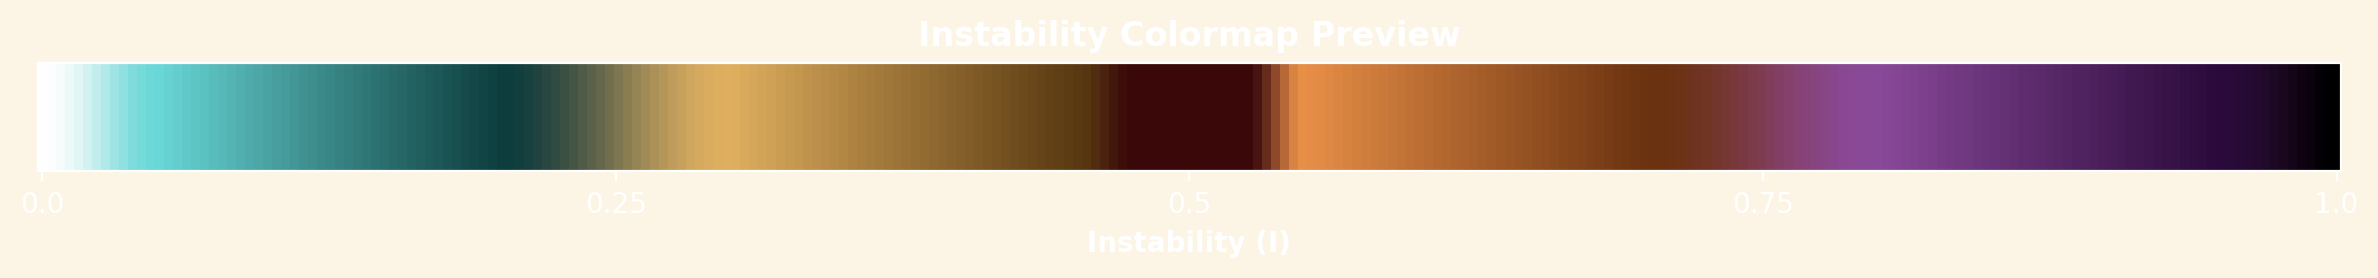

In [4]:
# ============================================================
# 🎨 INSTABILITY COLORMAP BUILDER
# ============================================================

def get_instability_color(i_val):
    """
    Get color for instability value.

    Zones (modify these ranges to change zone boundaries):
    - 0.00-0.25: Stable (Teal)
    - 0.25-0.50: Mostly Stable (Bronze)
    - 0.50-0.75: Borderline (Copper)
    - 0.75-1.00: Unstable (Purple → Black)
    """
    colors = CONFIG['instability']
    i_val = max(0, min(1, i_val))

    # === ZONE BOUNDARIES (modify these!) ===
    if i_val <= 0.05:
        return lerp_lab(colors['white'], colors['teal_light'], smoothstep(i_val / 0.05))
    if i_val <= 0.20:
        return lerp_lab(colors['teal_light'], colors['teal_dark'], (i_val - 0.05) / 0.15)
    if i_val <= 0.30:
        return lerp_lab(colors['teal_dark'], colors['bronze_light'], smoothstep((i_val - 0.20) / 0.10))
    if i_val <= 0.45:
        return lerp_lab(colors['bronze_light'], colors['bronze_dark'], (i_val - 0.30) / 0.15)
    if i_val <= 0.475:
        return lerp_lab(colors['bronze_dark'], colors['darkest_red'], smoothstep((i_val - 0.45) / 0.025))
    if i_val <= 0.525:
        return hex_to_rgb(colors['darkest_red'])
    if i_val <= 0.55:
        return lerp_lab(colors['darkest_red'], colors['copper_light'], smoothstep((i_val - 0.525) / 0.025))
    if i_val <= 0.70:
        return lerp_lab(colors['copper_light'], colors['copper_dark'], (i_val - 0.55) / 0.15)
    if i_val <= 0.80:
        return lerp_lab(colors['copper_dark'], colors['purple_light'], smoothstep((i_val - 0.70) / 0.10))
    if i_val <= 0.95:
        return lerp_lab(colors['purple_light'], colors['purple_dark'], (i_val - 0.80) / 0.15)
    return lerp_lab(colors['purple_dark'], colors['black'], smoothstep((i_val - 0.95) / 0.05))

def build_instability_colormap(n_colors=1024):
    """Build matplotlib colormap from instability colors"""
    colors = [get_instability_color(i / (n_colors - 1)) for i in range(n_colors)]
    return ListedColormap(colors)

# Preview the colormap
fig, ax = plt.subplots(figsize=(12, 1.5), facecolor=CONFIG['background'])
gradient = np.linspace(0, 1, 256).reshape(1, -1)
ax.imshow(gradient, aspect='auto', cmap=build_instability_colormap())
ax.set_xticks(np.linspace(0, 255, 5))
ax.set_xticklabels(['0.0', '0.25', '0.5', '0.75', '1.0'])
ax.set_yticks([])
ax.set_xlabel('Instability (I)', fontweight='bold')
ax.set_title('Instability Colormap Preview', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 📈 Visualization 1: Instability 3D Surface

**I = Ce / (Ce + Ca)**

Modify parameters below and re-run to iterate:

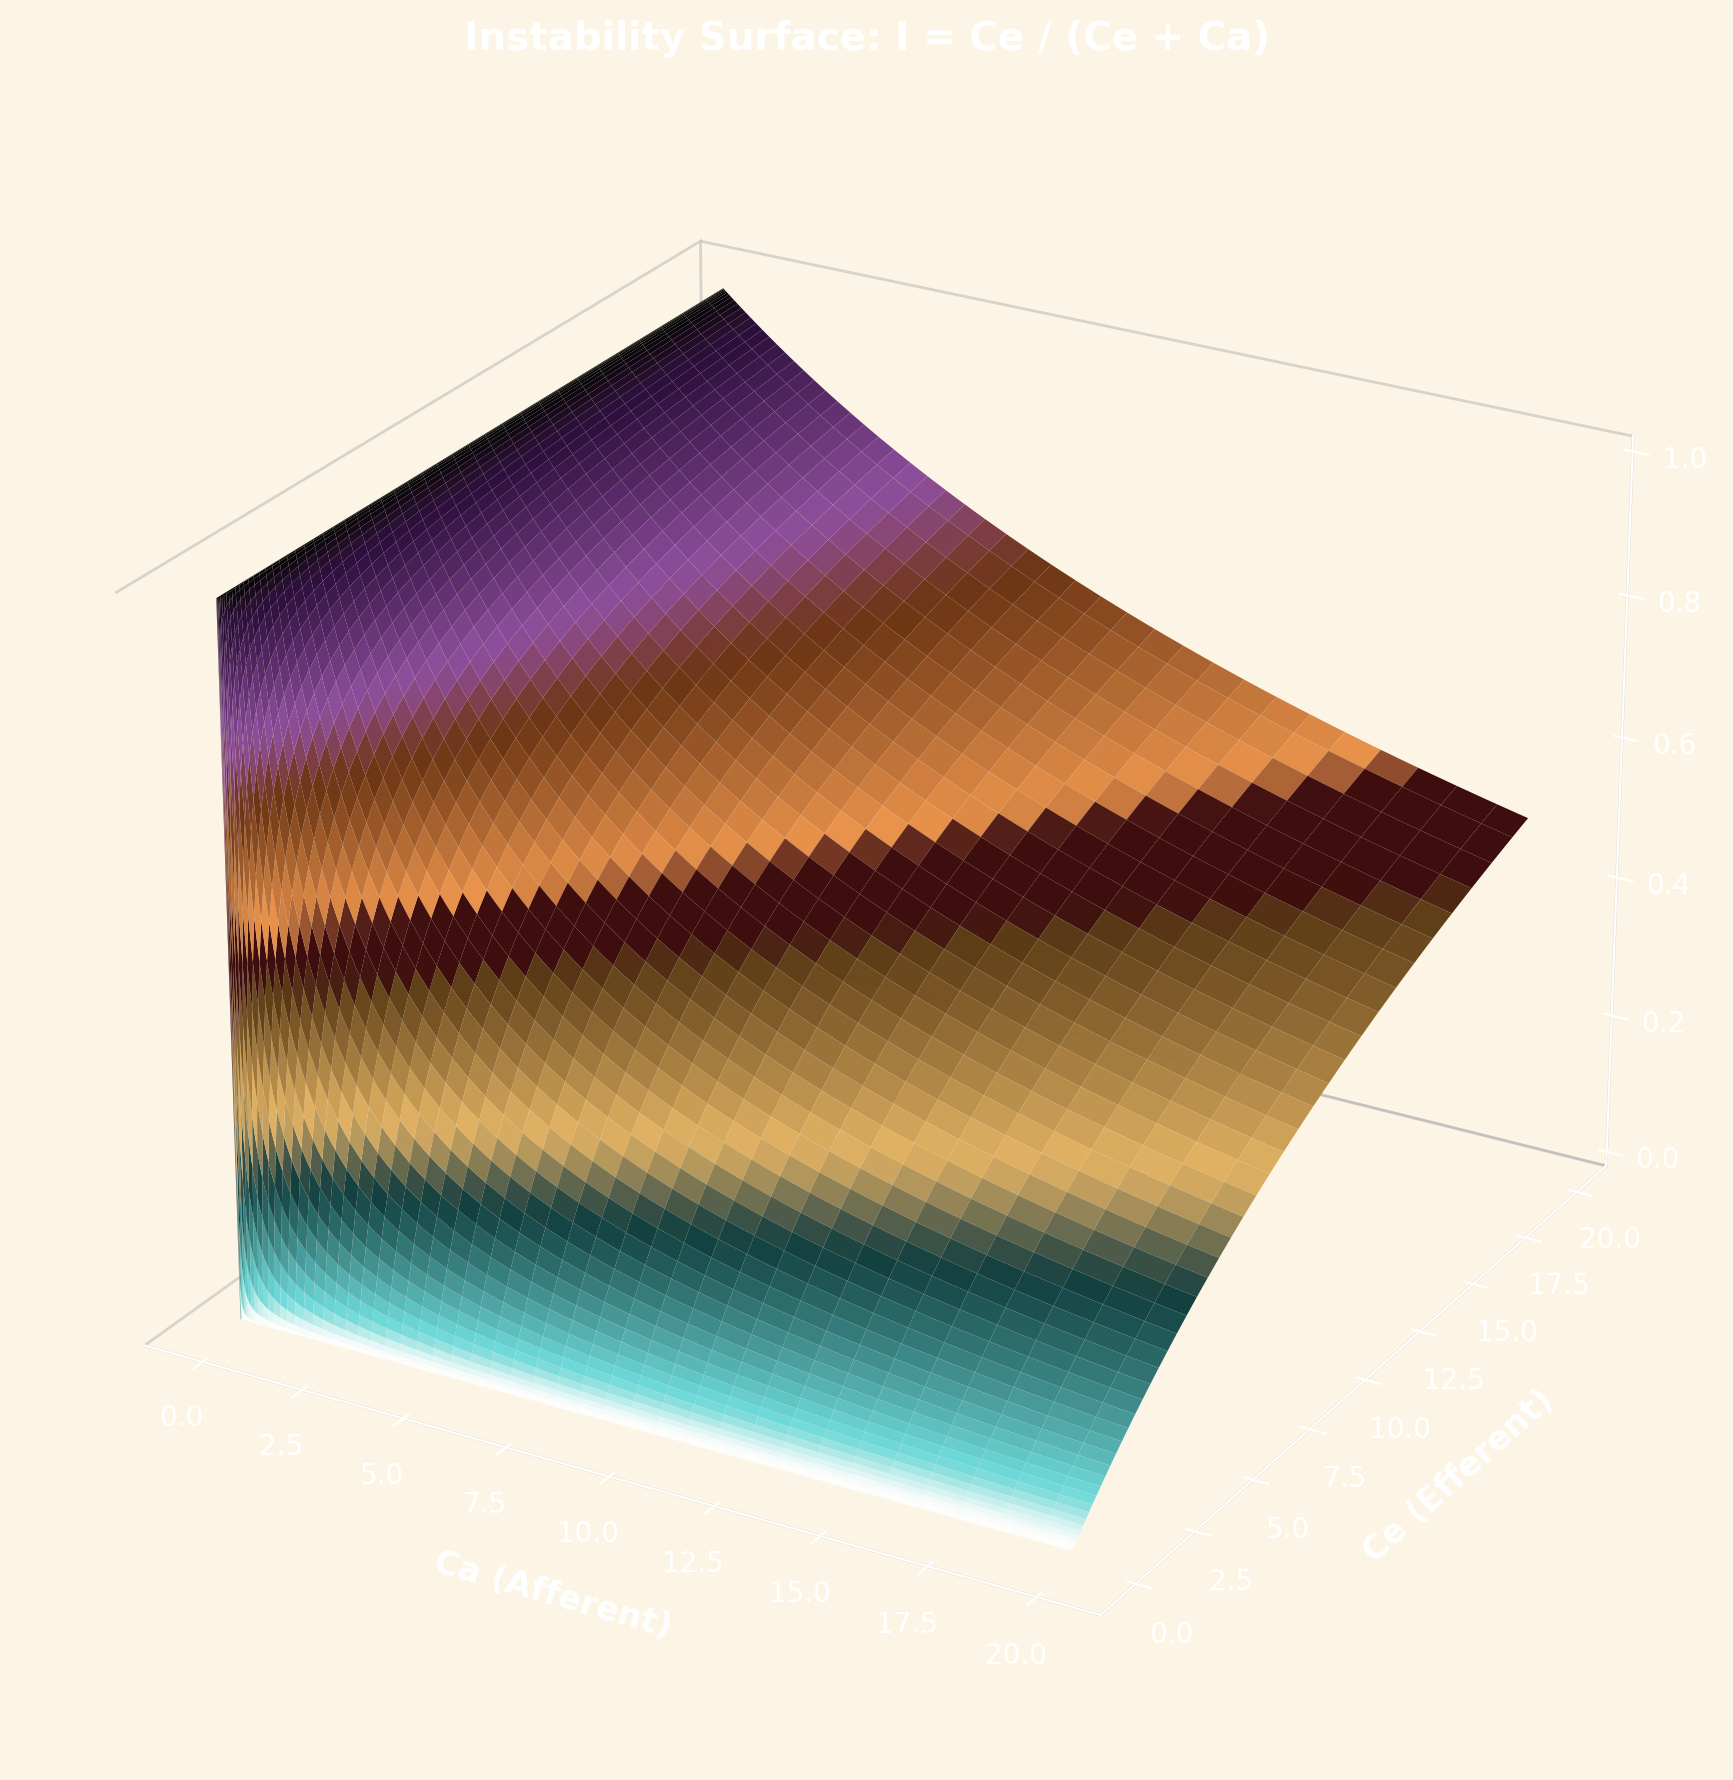

In [5]:
# ============================================================
# 📈 INSTABILITY 3D SURFACE
# ============================================================

# === PARAMETERS (modify these!) ===
INSTABILITY_PARAMS = {
    'max_coupling': 20,      # Max Ca and Ce values
    'mesh_points': 200,      # Resolution (higher = smoother but slower)
    'mesh_exponent': 2.5,    # Exponential clustering near origin
    'view_elev': 25,         # Camera elevation angle
    'view_azim': -60,        # Camera azimuth angle
    'light_azim': 315,       # Light source direction
    'light_alt': 45,         # Light source altitude
    'surface_alpha': 0.98,   # Surface transparency
    'figsize': (14, 9),
}

# Build mesh
p = INSTABILITY_PARAMS
t = np.linspace(0, 1, p['mesh_points'])
axis_vals = (t ** p['mesh_exponent']) * p['max_coupling']
Ca, Ce = np.meshgrid(axis_vals, axis_vals)
I = calc_instability(Ce, Ca)

# Create figure
fig = plt.figure(figsize=p['figsize'], facecolor=CONFIG['background'])
ax = fig.add_subplot(111, projection='3d', facecolor=CONFIG['background'])
ax.view_init(elev=p['view_elev'], azim=p['view_azim'])

# Plot surface
ls = LightSource(azdeg=p['light_azim'], altdeg=p['light_alt'])
surf = ax.plot_surface(Ca, Ce, I,
                       cmap=build_instability_colormap(),
                       linewidth=0, edgecolor='none',
                       antialiased=True, shade=True,
                       lightsource=ls, alpha=p['surface_alpha'])

# Style
ax.grid(False)
for pane in [ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane]:
    pane.fill = False
    pane.set_edgecolor((0.7, 0.7, 0.7, 0.3))
for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis._axinfo['grid']['color'] = (1, 1, 1, 0)

ax.set_xlabel('Ca (Afferent)', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Ce (Efferent)', fontsize=12, fontweight='bold', labelpad=10)
ax.set_zlabel('I (Instability)', fontsize=12, fontweight='bold', labelpad=10)
ax.set_title('Instability Surface: I = Ce / (Ce + Ca)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Uncomment to save:
# fig.savefig('instability-3d-surface.png', dpi=200, facecolor=CONFIG['background'], bbox_inches='tight')

---
## 📊 Visualization 2: Main Sequence (A vs I)

**Main Sequence: A + I = 1**
**Distance: D = |A + I - 1|**

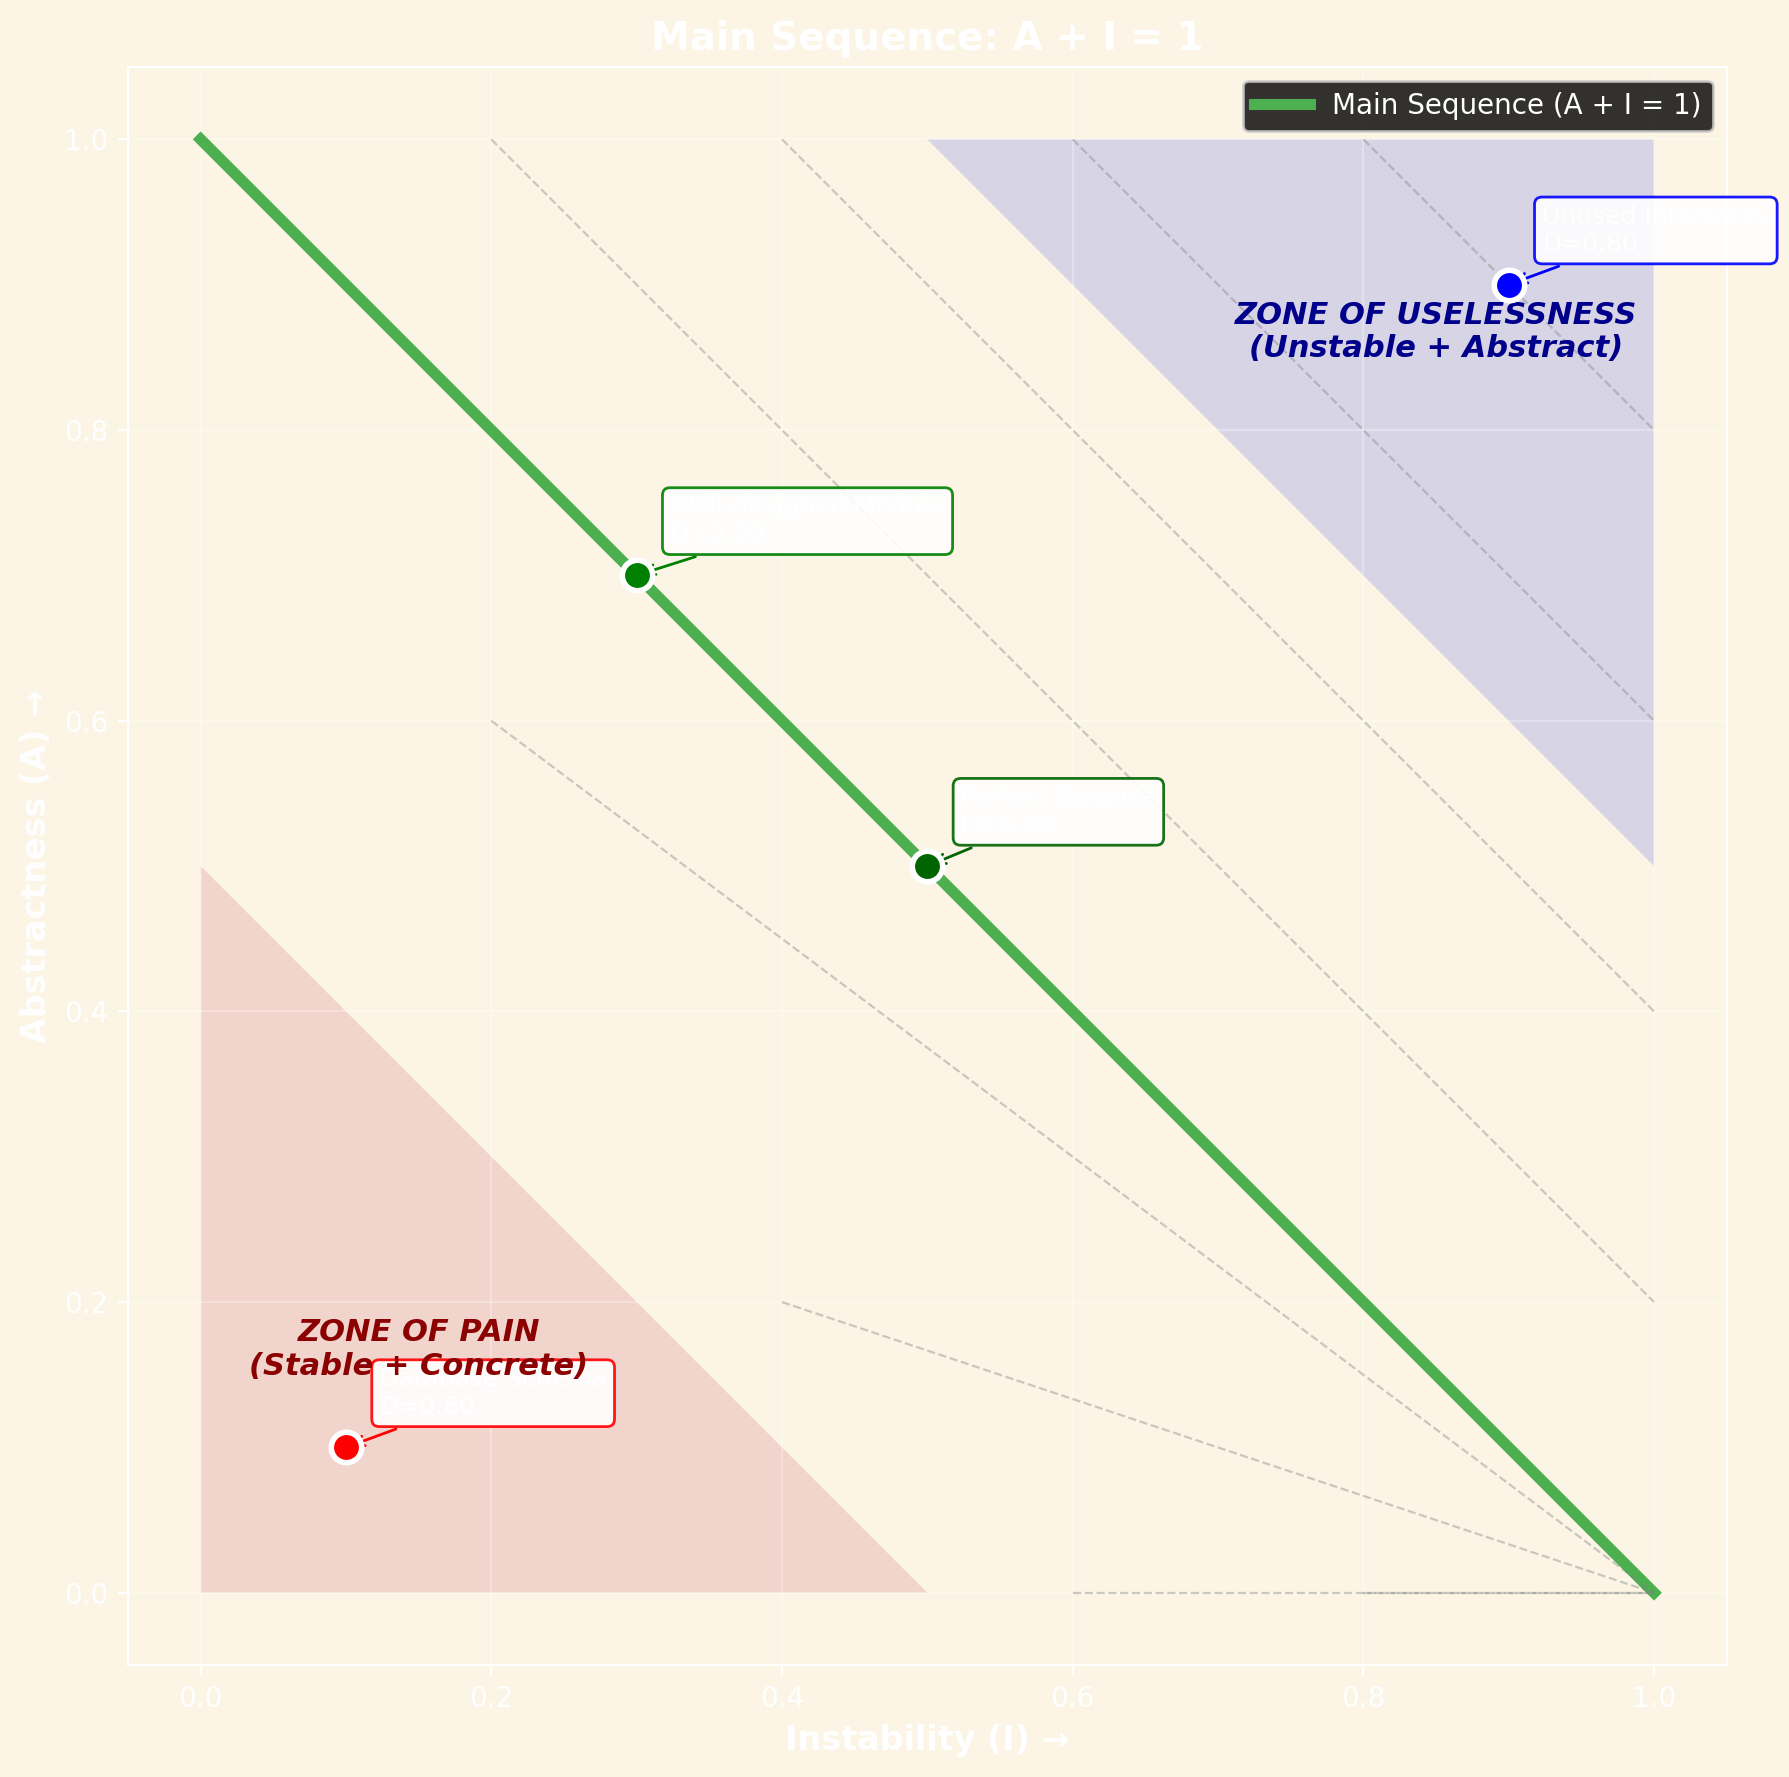

In [6]:
# ============================================================
# 📊 MAIN SEQUENCE 2D PLOT
# ============================================================

# === PARAMETERS (modify these!) ===
MAIN_SEQ_PARAMS = {
    'figsize': (11, 9),
    'zone_alpha': 0.5,       # Zone transparency
    'main_seq_width': 4,     # Main sequence line width
    'show_distance_bands': True,
    'show_examples': True,
}

# Example points to plot (x=I, y=A, label, color)
EXAMPLE_POINTS = [
    (0.1, 0.1, 'Database Schema', 'red'),
    (0.9, 0.9, 'Unused Interfaces', 'blue'),
    (0.3, 0.7, 'Well-designed Module', 'green'),
    (0.5, 0.5, 'Perfect Balance', 'darkgreen'),
]

# Create figure
fig, ax = plt.subplots(figsize=MAIN_SEQ_PARAMS['figsize'], facecolor=CONFIG['background'])
ax.set_facecolor(CONFIG['background'])

# Draw zones
zone_pain = Polygon([(0, 0), (0, 0.5), (0.5, 0)],
                    facecolor=CONFIG['zones']['pain'], alpha=MAIN_SEQ_PARAMS['zone_alpha'])
zone_useless = Polygon([(1, 1), (1, 0.5), (0.5, 1)],
                       facecolor=CONFIG['zones']['useless'], alpha=MAIN_SEQ_PARAMS['zone_alpha'])
ax.add_patch(zone_pain)
ax.add_patch(zone_useless)

# Main Sequence line
ax.plot([0, 1], [1, 0], color=CONFIG['zones']['main_seq'],
        linewidth=MAIN_SEQ_PARAMS['main_seq_width'], label='Main Sequence (A + I = 1)')

# Distance bands
if MAIN_SEQ_PARAMS['show_distance_bands']:
    for d in [0.2, 0.4, 0.6, 0.8]:
        # Above main sequence
        x = np.array([max(0, d), min(1, 1)])
        y = np.clip(1 - x + d, 0, 1)
        ax.plot(x, y, 'gray', linewidth=0.8, alpha=0.4, linestyle='--')
        # Below main sequence
        y2 = np.clip(1 - x - d, 0, 1)
        ax.plot(x, y2, 'gray', linewidth=0.8, alpha=0.4, linestyle='--')

# Example points
if MAIN_SEQ_PARAMS['show_examples']:
    for i, a, label, color in EXAMPLE_POINTS:
        d = abs(a + i - 1)
        ax.scatter([i], [a], s=120, c=color, edgecolors='white', linewidths=2, zorder=10)
        ax.annotate(f'{label}\nD={d:.2f}', (i, a),
                    xytext=(12, 12), textcoords='offset points', fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=color, alpha=0.9),
                    arrowprops=dict(arrowstyle='->', color=color))

# Zone labels
ax.text(0.15, 0.15, 'ZONE OF PAIN\n(Stable + Concrete)',
        fontsize=11, fontweight='bold', ha='center', color='#8B0000', style='italic')
ax.text(0.85, 0.85, 'ZONE OF USELESSNESS\n(Unstable + Abstract)',
        fontsize=11, fontweight='bold', ha='center', color='#00008B', style='italic')

# Styling
ax.set_xlabel('Instability (I) →', fontsize=12, fontweight='bold')
ax.set_ylabel('Abstractness (A) →', fontsize=12, fontweight='bold')
ax.set_title('Main Sequence: A + I = 1', fontsize=14, fontweight='bold')
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.set_aspect('equal')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Uncomment to save:
# fig.savefig('main-sequence-2d.png', dpi=200, facecolor=CONFIG['background'], bbox_inches='tight')

---
## 🗺️ Visualization 3: Distance Heatmap

In [ ]:
# ============================================================
# 🗺️ DISTANCE HEATMAP
# ============================================================

# === PARAMETERS ===
HEATMAP_PARAMS = {
    'figsize': (11, 9),
    'contour_levels': [0.1, 0.2, 0.3, 0.5, 0.7],
    'cmap': 'RdYlGn_r',  # Red-Yellow-Green reversed (green=good)
}

# Build distance grid
n = 200
I_range = np.linspace(0, 1, n)
A_range = np.linspace(0, 1, n)
I_grid, A_grid = np.meshgrid(I_range, A_range)
D_grid = calc_distance(A_grid, I_grid)

# Create figure
fig, ax = plt.subplots(figsize=HEATMAP_PARAMS['figsize'], facecolor=CONFIG['background'])

# Heatmap
im = ax.imshow(D_grid, extent=[0, 1, 0, 1], origin='lower',
               cmap=HEATMAP_PARAMS['cmap'], aspect='equal', alpha=0.85)

# Main Sequence
ax.plot([0, 1], [1, 0], color='white', linewidth=4)
ax.plot([0, 1], [1, 0], color=CONFIG['zones']['main_seq'], linewidth=2, linestyle='--')

# Contours
cs = ax.contour(I_grid, A_grid, D_grid, levels=HEATMAP_PARAMS['contour_levels'],
                colors='white', linewidths=1.5, alpha=0.8)
ax.clabel(cs, inline=True, fontsize=10, fmt='D=%.1f')

# Zone labels
ax.text(0.15, 0.15, 'ZONE OF\nPAIN', fontsize=12, fontweight='bold', ha='center', color='white',
        bbox=dict(boxstyle='round', facecolor='#8B0000', alpha=0.8))
ax.text(0.85, 0.85, 'ZONE OF\nUSELESSNESS', fontsize=12, fontweight='bold', ha='center', color='white',
        bbox=dict(boxstyle='round', facecolor='#00008B', alpha=0.8))

# Colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Distance D = |A + I - 1|', fontweight='bold')

ax.set_xlabel('Instability (I)', fontsize=12, fontweight='bold')
ax.set_ylabel('Abstractness (A)', fontsize=12, fontweight='bold')
ax.set_title('Distance from Main Sequence', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Uncomment to save:
# fig.savefig('distance-heatmap.png', dpi=200, facecolor=CONFIG['background'], bbox_inches='tight')

---
## 🧊 Visualization 4: Distance 3D Surface

In [ ]:
# ============================================================
# 🧊 DISTANCE 3D SURFACE
# ============================================================

DISTANCE_3D_PARAMS = {
    'figsize': (14, 9),
    'view_elev': 25,
    'view_azim': -60,
    'cmap': 'RdYlGn_r',
}

# Create figure
fig = plt.figure(figsize=DISTANCE_3D_PARAMS['figsize'], facecolor=CONFIG['background'])
ax = fig.add_subplot(111, projection='3d', facecolor=CONFIG['background'])
ax.view_init(elev=DISTANCE_3D_PARAMS['view_elev'], azim=DISTANCE_3D_PARAMS['view_azim'])

# Plot surface
ls = LightSource(azdeg=315, altdeg=45)
surf = ax.plot_surface(I_grid, A_grid, D_grid,
                       cmap=DISTANCE_3D_PARAMS['cmap'],
                       linewidth=0, edgecolor='none',
                       antialiased=True, shade=True,
                       lightsource=ls, alpha=0.95)

# Main Sequence line (D=0 valley)
main_i = np.linspace(0, 1, 100)
main_a = 1 - main_i
ax.plot(main_i, main_a, np.zeros_like(main_i),
        color='white', linewidth=4, label='Main Sequence')

# Style
ax.grid(False)
for pane in [ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane]:
    pane.fill = False
    pane.set_edgecolor((0.7, 0.7, 0.7, 0.3))

ax.set_xlabel('Instability (I)', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Abstractness (A)', fontsize=12, fontweight='bold', labelpad=10)
ax.set_zlabel('Distance (D)', fontsize=12, fontweight='bold', labelpad=10)
ax.set_title('Distance from Main Sequence: D = |A + I - 1|', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Uncomment to save:
# fig.savefig('distance-3d-surface.png', dpi=200, facecolor=CONFIG['background'], bbox_inches='tight')

---
## 📁 Export All Visualizations

Run this cell to export all visualizations at once:

In [ ]:
# ============================================================
# 📁 BATCH EXPORT
# ============================================================

OUTPUT_DIR = '.'  # Change to your output directory
EXPORT_FORMAT = 'png'  # 'png' or 'svg'
EXPORT_DPI = 200

print(f"Exporting to {OUTPUT_DIR}/ as {EXPORT_FORMAT.upper()}...")

# Run each visualization and save
# (You would paste the plotting code here with savefig calls)

print("\n✅ Export complete!")
print(f"   Format: {EXPORT_FORMAT.upper()}")
print(f"   DPI: {EXPORT_DPI}")

---
## 📚 Reference

### Formulas

| Metric | Formula | Range | Meaning |
|--------|---------|-------|--------|
| **Ca** (Afferent) | incoming deps | 0 → ∞ | Who depends on me? |
| **Ce** (Efferent) | outgoing deps | 0 → ∞ | Who do I depend on? |
| **I** (Instability) | Ce/(Ca+Ce) | 0 → 1 | 0=stable, 1=volatile |
| **A** (Abstractness) | abstract/total | 0 → 1 | 0=concrete, 1=abstract |
| **D** (Distance) | \|A+I-1\| | 0 → 1 | Distance from ideal |

### Zones

| Zone | Condition | Problem |
|------|-----------|--------|
| **Main Sequence** | A + I = 1 | Ideal balance |
| **Zone of Pain** | Low A, Low I | Stable but concrete → rigid |
| **Zone of Uselessness** | High A, High I | Abstract but unstable → orphaned |

### Sources
- Martin, R.C. *Clean Architecture* (2017)
- Martin, R.C. *Agile Software Development* (2002)